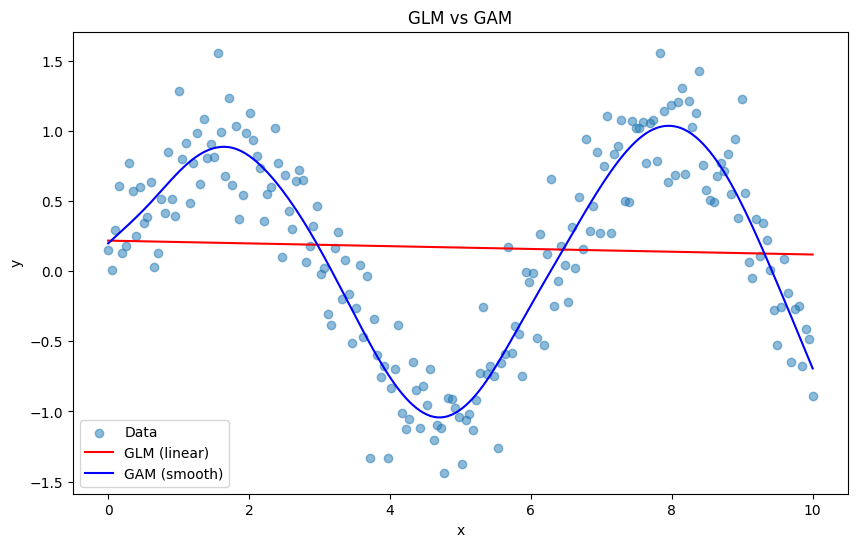

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pygam import LinearGAM, s

# ----------------------------
# 1. Simulate nonlinear data
# ----------------------------
np.random.seed(42)
x = np.linspace(0, 10, 200)
y = np.sin(x) + np.random.normal(0, 0.3, size=len(x))

df = pd.DataFrame({"x": x, "y": y})

# ----------------------------
# 2. Fit GLM (linear regression)
# ----------------------------
X_glm = sm.add_constant(df["x"])   # add intercept
glm_model = sm.GLM(df["y"], X_glm, family=sm.families.Gaussian()).fit()

# Predictions from GLM
df["glm_pred"] = glm_model.predict(X_glm)

# ----------------------------
# 3. Fit GAM (with smoothing)
# ----------------------------
gam = LinearGAM(s(0)).fit(df[["x"]], df["y"])
df["gam_pred"] = gam.predict(df[["x"]])

# ----------------------------
# 4. Plot results
# ----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(df["x"], df["y"], alpha=0.5, label="Data")
plt.plot(df["x"], df["glm_pred"], color="red", label="GLM (linear)")
plt.plot(df["x"], df["gam_pred"], color="blue", label="GAM (smooth)")
plt.legend()
plt.title("GLM vs GAM")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
